In [7]:
# ==========================
# Customer Segmentation using K-Means
# SkillCraft Technology - Task 02
# ==========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import plotly.express as px

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
# Load dataset
df = pd.read_csv("../data/Mall_Customers.csv")

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Mall_Customers.csv'

In [ ]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
df.info()

Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [ ]:
# Missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
for column in df.columns:
    print(f"\n{column}")
    print(f"Unique Values: {df[column].nunique()}")


CustomerID
Unique Values: 200

Gender
Unique Values: 2

Age
Unique Values: 51

Annual Income (k$)
Unique Values: 64

Spending Score (1-100)
Unique Values: 84


In [ ]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Duplicate Values": [df.duplicated().sum()] * len(df.columns),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Duplicate Values,Unique Values
CustomerID,int64,0,0,200
Gender,str,0,0,2
Age,int64,0,0,51
Annual Income (k$),int64,0,0,64
Spending Score (1-100),int64,0,0,84


In [ ]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


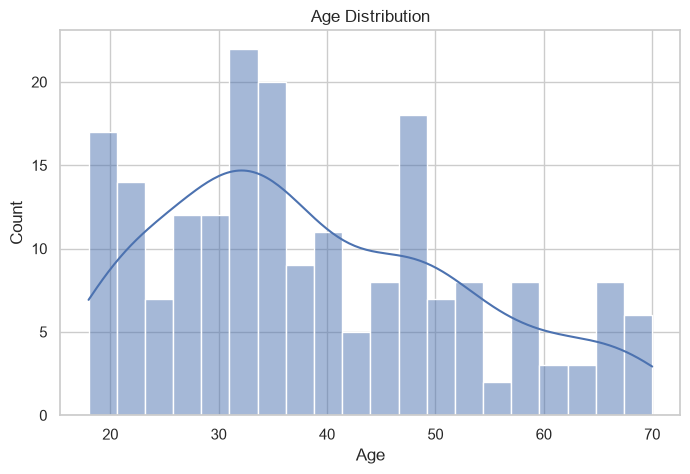

In [ ]:
plt.figure(figsize=(8,5)) 

# ensure df is available (reload if cell wasn't executed)
if 'df' not in globals():
    # try common locations for the dataset
    paths = [
        "../data/Mall_Customers.csv",
        "data/Mall_Customers.csv",
        "./data/Mall_Customers.csv",
        "Mall_Customers.csv",
        "../Mall_Customers.csv"
    ]
    df = None
    for p in paths:
        try:
            df = pd.read_csv(p)
            print(f"Loaded dataset from: {p}")
            break
        except Exception:
            continue
    if df is None:
        raise FileNotFoundError(
            "Mall_Customers.csv not found. Please place the file in one of: "
            + ", ".join(paths)
        )

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

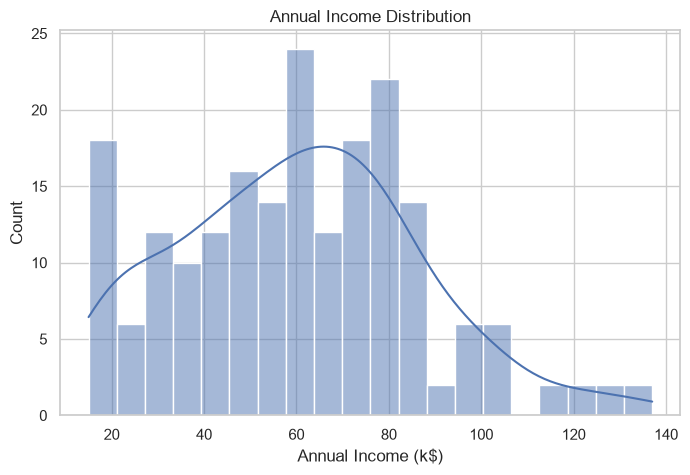

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

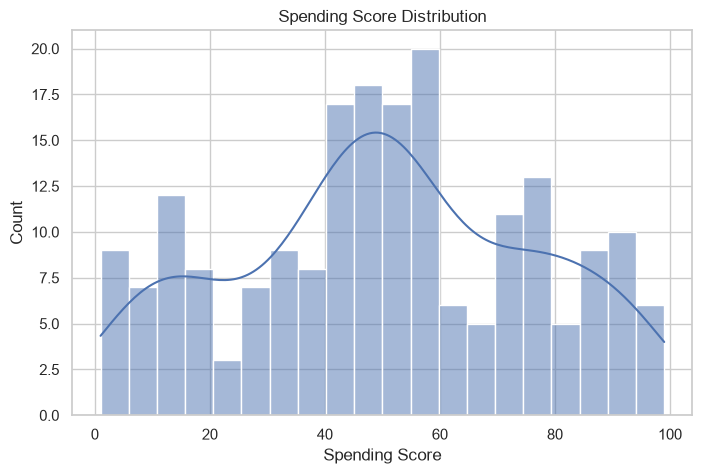

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

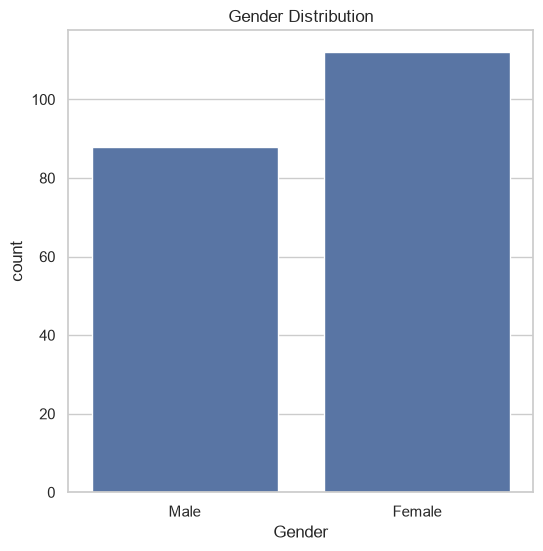

In [ ]:
plt.figure(figsize=(6,6))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

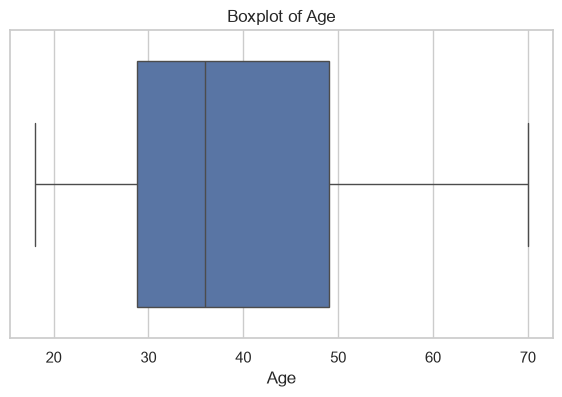

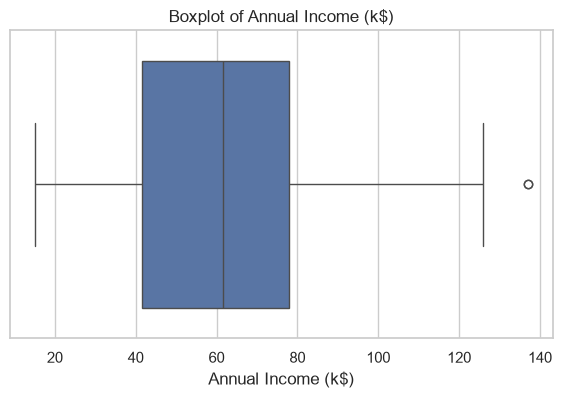

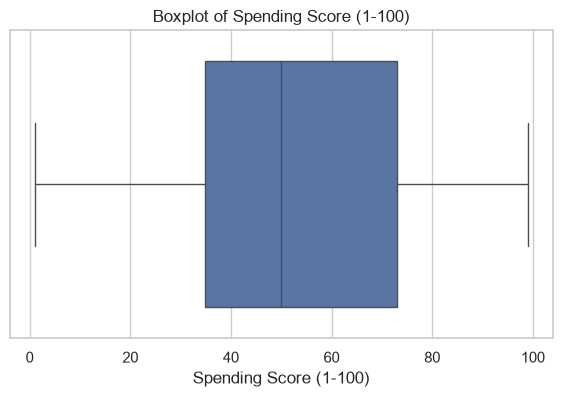

In [ ]:
numerical_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.savefig(f"images/{column.replace(' ', '_').lower()}_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

Loaded dataset from: data/Mall_Customers.csv


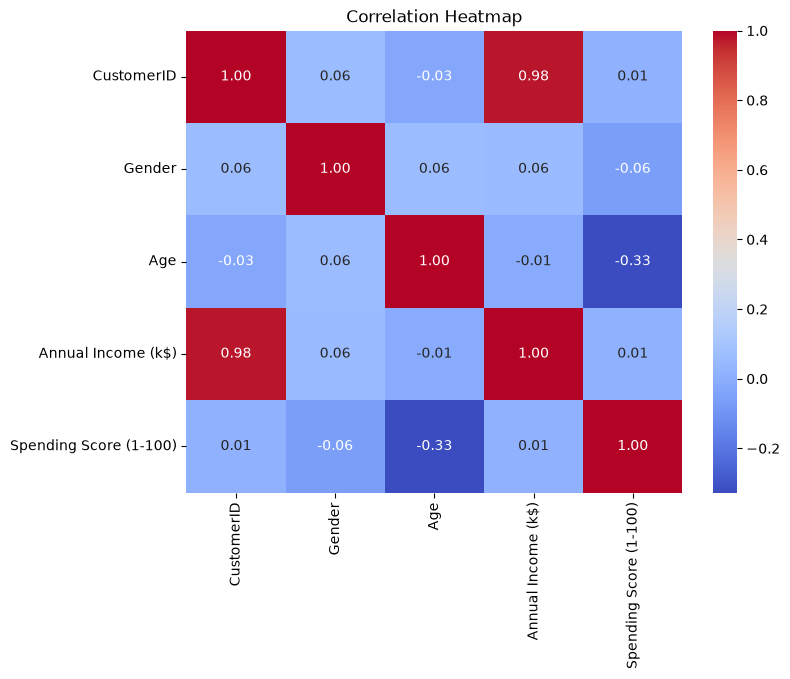

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load data first
paths = [
    "../data/Mall_Customers.csv",
    "data/Mall_Customers.csv",
    "./data/Mall_Customers.csv",
    "Mall_Customers.csv",
    "../Mall_Customers.csv"
]
df = None
for p in paths:
    try:
        df = pd.read_csv(p)
        print(f"Loaded dataset from: {p}")
        break
    except FileNotFoundError:
        continue
if df is None:
    raise FileNotFoundError("Mall_Customers.csv not found in common locations")

# Step 2: Your correlation heatmap code
corr_df = df.copy()
corr_df["Gender"] = corr_df["Gender"].map({"Male": 1, "Female": 0})

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

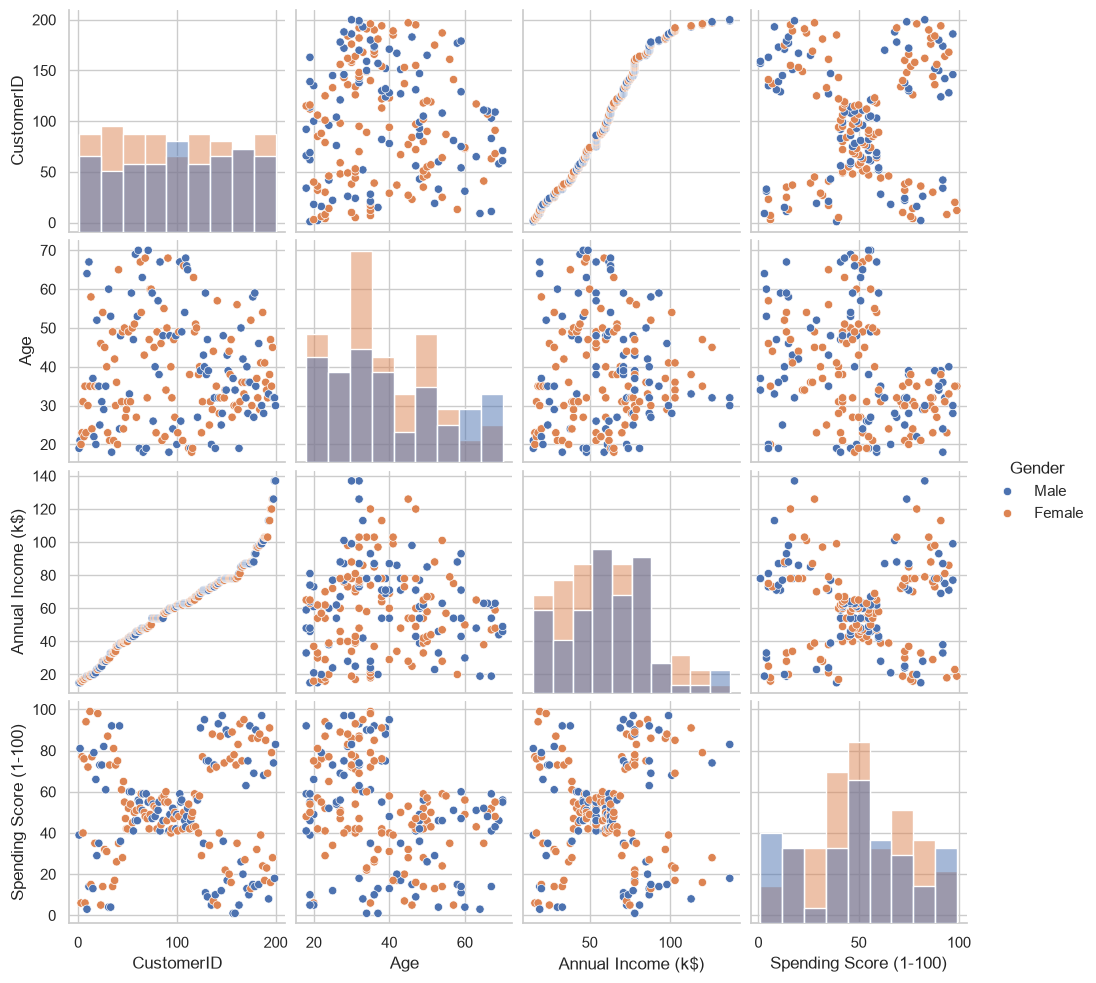

In [ ]:
sns.pairplot(
    df,
    hue="Gender",
    diag_kind="hist"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Create a copy of the dataset
data = df.copy()

# Display first 5 rows
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Encode Gender
data["Gender"] = data["Gender"].map({
    "Male": 1,
    "Female": 0
})

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
# Select features for clustering
features = data.drop("CustomerID", axis=1)

features.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
scaled_features = scaler.fit_transform(features)

In [ ]:
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [ ]:
print("Mean of scaled features:")
print(scaled_df.mean())

print("\nStandard deviation:")
print(scaled_df.std())

Mean of scaled features:
Gender                    3.108624e-17
Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standard deviation:
Gender                    1.002509
Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


In [ ]:
# Find the optimal number of clusters using the Elbow Method

inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    inertia.append(kmeans.inertia_)

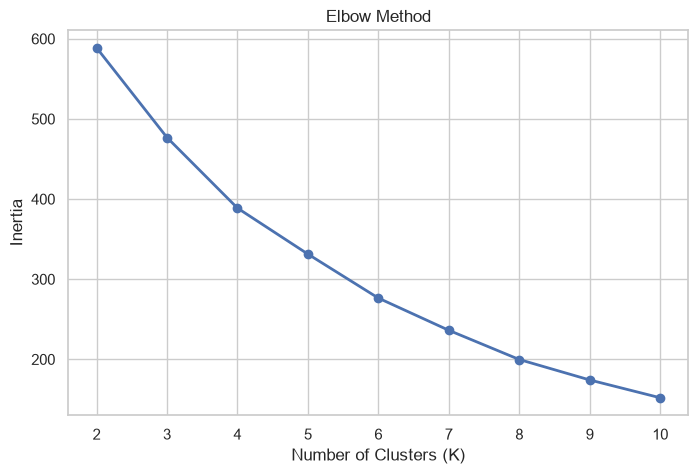

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.grid(True)

plt.savefig(
    "images/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    silhouette_scores.append(score)

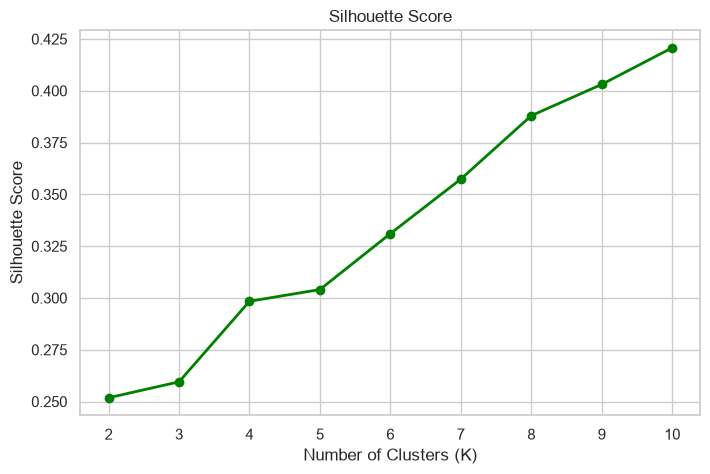

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.savefig(
    "images/silhouette_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

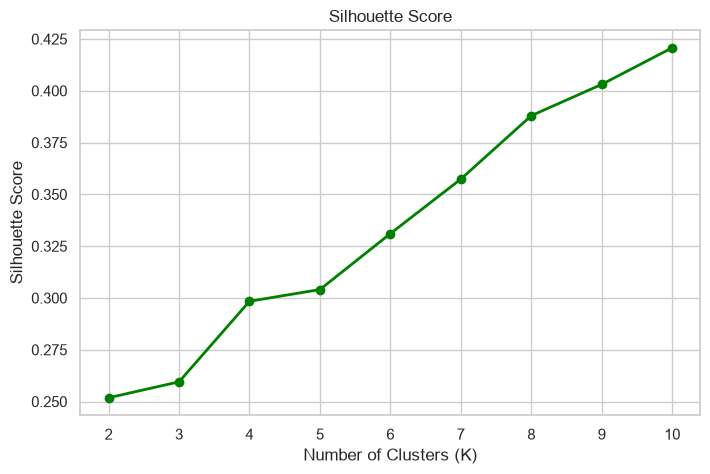

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.savefig(
    "images/silhouette_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,588.802677,0.251815
1,3,476.787554,0.259513
2,4,388.717861,0.298397
3,5,331.309884,0.304060
4,6,276.411760,0.331074
5,7,236.204947,0.357377
6,8,199.750461,0.387993
7,9,174.235477,0.403092
8,10,152.029834,0.420764


In [ ]:
best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

print(f"Best K based on Silhouette Score: {best_k}")

Best K based on Silhouette Score: 10


In [ ]:
# Final K-Means Model

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

In [ ]:
# Add cluster labels

data["Cluster"] = clusters

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


In [ ]:
cluster_counts = data["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


In [ ]:
sil_score = silhouette_score(scaled_df, clusters)

print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.304


In [ ]:
db_score = davies_bouldin_score(
    scaled_df,
    clusters
)

print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 1.167


In [ ]:
ch_score = calinski_harabasz_score(
    scaled_df,
    clusters
)

print(f"Calinski-Harabasz Score: {ch_score:.3f}")

Calinski-Harabasz Score: 68.965


In [ ]:
evaluation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "Value": [
        sil_score,
        db_score,
        ch_score
    ]
})

evaluation

,Metric,Value
0,Silhouette Score,0.304060
1,Davies-Bouldin Index,1.167230
2,Calinski-Harabasz Score,68.964568


In [ ]:
cluster_profile = (
    data
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.00,0.46,32.69,86.54,82.13
1,165.48,0.45,36.48,89.52,18.00
2,73.65,0.00,49.81,49.23,40.07
3,52.81,0.41,24.91,39.72,61.20
4,84.69,1.00,55.71,53.69,36.77


In [ ]:
cluster_profile.to_csv(
    "cluster_profile.csv"
)

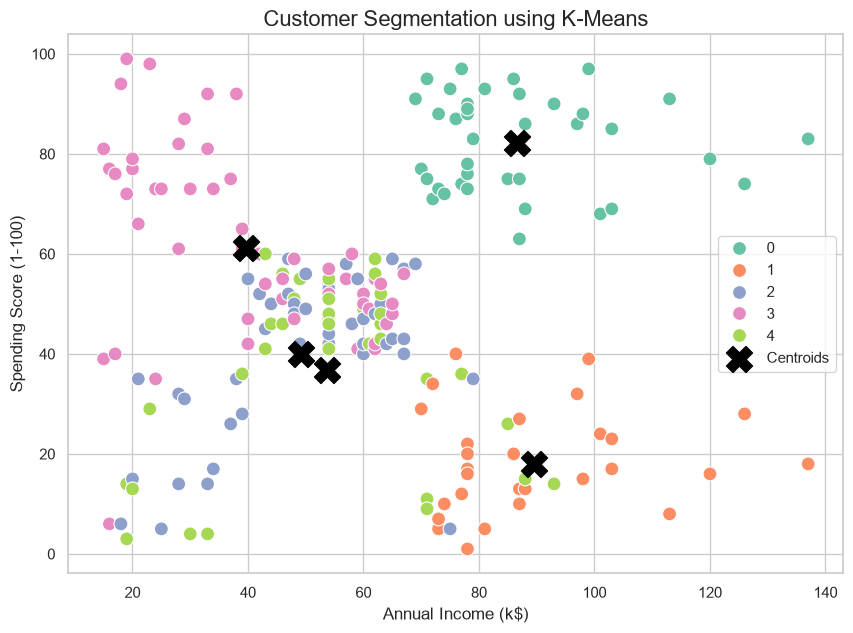

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=data,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=100
)

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 2],   # Annual Income
    centroids[:, 3],   # Spending Score
    c="black",
    s=350,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means", fontsize=16)

plt.legend()

plt.savefig(
    "images/customer_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

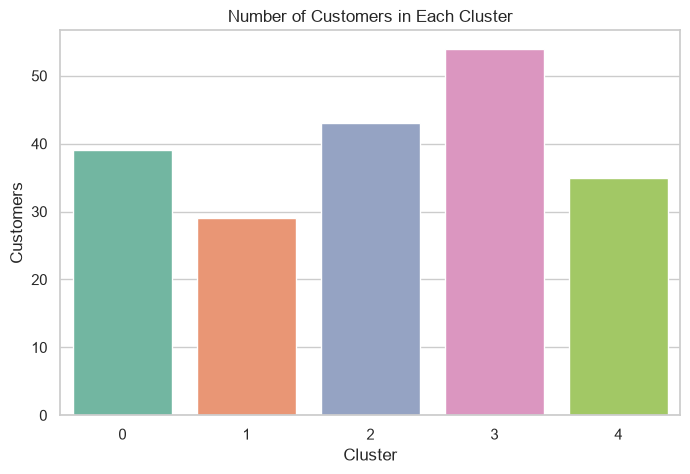

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="Cluster",
    palette="Set2"
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Customers")

plt.savefig(
    "images/cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

In [ ]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

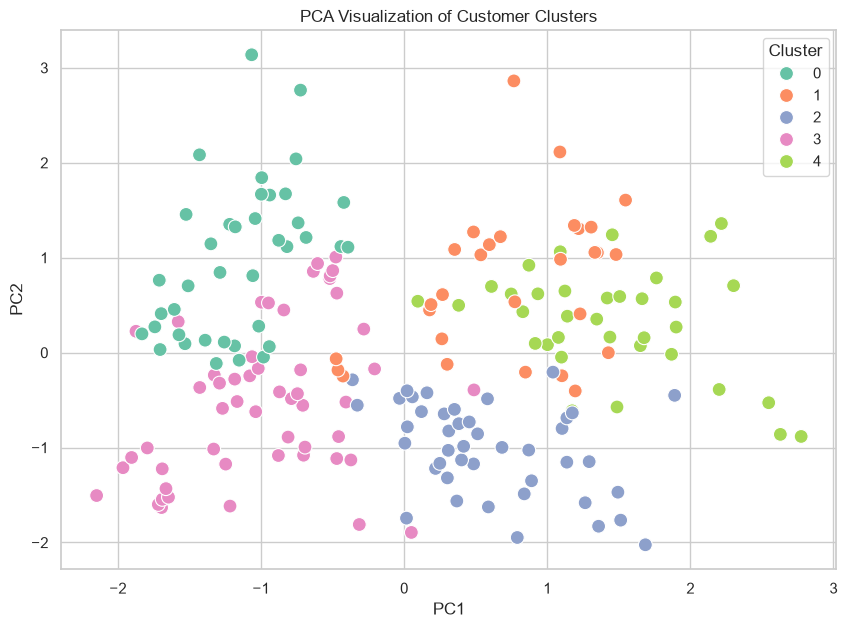

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("PCA Visualization of Customer Clusters")

plt.savefig(
    "images/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig = px.scatter(
    data,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    color="Cluster",
    hover_data=[
        "Age",
        "Gender"
    ],
    title="Interactive Customer Segmentation"
)

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
data.to_csv(
    "clustered_customers.csv",
    index=False
)

In [ ]:
cluster_profile

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.00,0.46,32.69,86.54,82.13
1,165.48,0.45,36.48,89.52,18.00
2,73.65,0.00,49.81,49.23,40.07
3,52.81,0.41,24.91,39.72,61.20
4,84.69,1.00,55.71,53.69,36.77


In [ ]:
cluster_summary = (
    data.groupby("Cluster")
        .agg({
            "Age": "mean",
            "Annual Income (k$)": "mean",
            "Spending Score (1-100)": "mean",
            "CustomerID": "count"
        })
        .rename(columns={"CustomerID": "Customers"})
        .round(2)
)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,,
0,32.69,86.54,82.13,39
1,36.48,89.52,18.00,29
2,49.81,49.23,40.07,43
3,24.91,39.72,61.20,54
4,55.71,53.69,36.77,35


# Customer Personas

## Cluster 0 – Premium Customers
- High Income
- High Spending
- Loyal customers

Business Strategy:
- VIP Membership
- Premium product recommendations
- Exclusive offers

---

## Cluster 1 – Standard Customers
- Average Income
- Average Spending

Business Strategy:
- Loyalty rewards
- Seasonal promotions

---

## Cluster 2 – Potential Customers
- High Income
- Low Spending

Business Strategy:
- Personalized marketing
- Luxury product campaigns

---

## Cluster 3 – Budget Customers
- Low Income
- Low Spending

Business Strategy:
- Discounts
- Coupon campaigns

---

## Cluster 4 – Young High Spenders
- Young Age
- Medium Income
- High Spending

Business Strategy:
- Trend-based products
- Social media marketing

## Key Findings

- Annual Income and Spending Score are the most influential features for segmentation.
- Age contributes to separating customer demographics.
- CustomerID was excluded because it is only an identifier.
- Gender was encoded to include it in clustering.

# Conclusion

This project successfully segmented mall customers into five distinct groups using the K-Means clustering algorithm.

The optimal number of clusters was selected using both the Elbow Method and the Silhouette Score. Although the Silhouette Score continued to improve for larger K values, K = 5 was chosen because it provides a strong balance between clustering quality, business interpretability, and customer segmentation best practices.

The resulting customer groups can help retail businesses design targeted marketing campaigns, improve customer retention, optimize promotional offers, and increase overall profitability.

# Future Improvements

- Use DBSCAN and Agglomerative Clustering for comparison.
- Develop an interactive Streamlit dashboard.
- Build a recommendation engine based on customer clusters.
- Deploy the project as a web application.
- Incorporate additional customer behavior features for improved segmentation.